# 04 — GAM Modeling: Does lagged PM2.5 relate to subsequent weather?

**Objective:** test whether **airborne PM2.5** (especially smoke) is associated with **later** meteorological conditions at Eugene — not whether weather predicts PM2.5.

**Specification:** for each weather variable \(Y_t\), fit a GAM with **lagged PM2.5** as exposure and **calendar controls**:

`Y_t ~ s(PM2.5_{t-h}) + s(hour) + s(day of year)`

We use **`pm2.5_lrapa_lag_3h`** (LRAPA-corrected PurpleAir, 3-hour lag) so exposure strictly **precedes** the outcome hour. Exposure lag is set by `PM_LAG_COL` (default `pm2.5_lrapa_lag_3h`; alternatives include `pm2.5_lrapa_lag_6h` and `pm2.5_lrapa_lag_12h`).

**Caveats:** this is still **observational**. Hour and day-of-year absorb diurnal and seasonal patterns but **cannot remove all confounding** (e.g. synoptic weather drives both smoke transport and \(Y_t\)). Interpret partial effects as **associations consistent with a PM2.5 → weather hypothesis**, not proof of causation.

**Software:** `pygam` (see `requirements.txt`).


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
from pygam import LinearGAM, s

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

## 0. Load data and define exposure / outcomes

In [ ]:
df = pd.read_csv('../data/processed/analysis_data.csv', parse_dates=['timestamp'])
print(f'Loaded {len(df):,} records')

# --- Direction: PM2.5 (lagged) → weather (current hour) ---
PM_LAG_COL = 'pm2.5_lrapa_lag_3h'  # alternate lags: _lag_6h, _lag_12h
CONTROL_COLS = ['hour', 'dayofyear']

OUTCOMES = [
    'temperature_f',
    'humidity',
    'wind_speed_mph',
    'pressure_hpa',
]
OUTCOMES = [c for c in OUTCOMES if c in df.columns]
for c in [PM_LAG_COL] + CONTROL_COLS:
    if c not in df.columns:
        raise KeyError(f'Missing column {c!r} — regenerate `analysis_data.csv` with the data-cleaning pipeline')

use_cols = ['timestamp', PM_LAG_COL] + CONTROL_COLS + OUTCOMES
model_df = df[use_cols].dropna().copy()
model_df = model_df.sort_values('timestamp').reset_index(drop=True)

print(f'Rows after dropna on lag + controls + outcomes: {len(model_df):,}')
print(f'Exposure: {PM_LAG_COL}  |  Controls: {CONTROL_COLS}  |  Outcomes: {OUTCOMES}')
model_df[[PM_LAG_COL] + CONTROL_COLS + OUTCOMES].describe().round(2)


Loaded 3,240 records
Rows after dropna on lag + controls + outcomes: 3,233
Exposure: pm2.5_lrapa_lag_3h  |  Controls: ['hour', 'dayofyear']  |  Outcomes: ['temperature_f', 'humidity', 'wind_speed_mph', 'pressure_hpa']


,pm2.5_lrapa_lag_3h,hour,dayofyear,temperature_f,humidity,wind_speed_mph,pressure_hpa
count,3233.00,3233.00,3233.00,3233.00,3233.00,3233.00,3233.00
mean,24.65,11.49,246.97,66.53,64.60,6.63,1016.28
std,73.57,6.92,20.29,11.08,21.53,4.91,3.76
min,0.00,0.00,212.00,45.00,13.26,0.00,1002.50
25%,0.78,5.00,230.00,58.00,46.76,3.45,1013.90
50%,2.29,11.00,246.00,64.00,67.86,5.75,1016.10
75%,7.72,17.00,263.00,74.00,83.29,9.21,1018.70
max,502.52,23.00,288.00,101.00,100.00,27.62,1032.20


## 1. Temporal train/test split and fit one GAM per weather outcome

First **80%** of hours → train, last **20%** → test (same split for every outcome so results are comparable).

In [3]:
FEATURE_COLS = [PM_LAG_COL] + CONTROL_COLS
split_idx = int(len(model_df) * 0.8)
train = model_df.iloc[:split_idx]
test  = model_df.iloc[split_idx:]

X_train = train[FEATURE_COLS].values
X_test  = test[FEATURE_COLS].values

print(f'Train: {len(train):,}  |  Test: {len(test):,}')

fitted_gams = {}
metrics = {}

terms = s(0) + s(1) + s(2)

for out in OUTCOMES:
    y_tr = train[out].values
    y_te = test[out].values

    gam = LinearGAM(terms)
    print(f'Fitting GAM for {out} ...', end=' ', flush=True)
    gam.gridsearch(X_train, y_tr, progress=False)
    fitted_gams[out] = gam

    tr_r2 = r2_score(y_tr, gam.predict(X_train))
    te_r2 = r2_score(y_te, gam.predict(X_test))
    te_rmse = np.sqrt(mean_squared_error(y_te, gam.predict(X_test)))
    metrics[out] = {'train_r2': tr_r2, 'test_r2': te_r2, 'test_rmse': te_rmse}
    print(f'train R²={tr_r2:.3f}  test R²={te_r2:.3f}  test RMSE={te_rmse:.3f}')

print('Done.')

Train: 2,586  |  Test: 647
Fitting GAM for temperature_f ... train R²=0.831  test R²=0.652  test RMSE=5.793
Fitting GAM for humidity ... train R²=0.806  test R²=0.207  test RMSE=18.326
Fitting GAM for wind_speed_mph ... train R²=0.371  test R²=-0.276  test RMSE=5.174
Fitting GAM for pressure_hpa ... train R²=0.533  test R²=-0.938  test RMSE=6.435
Done.


## 2. Partial dependence on **lagged PM2.5** (term 0)

Each panel: fitted smooth of the weather outcome vs **prior** PM2.5, **marginally** over the fitted model (other smooths averaged in `pygam`'s partial dependence). Shaded band: 95% CI.

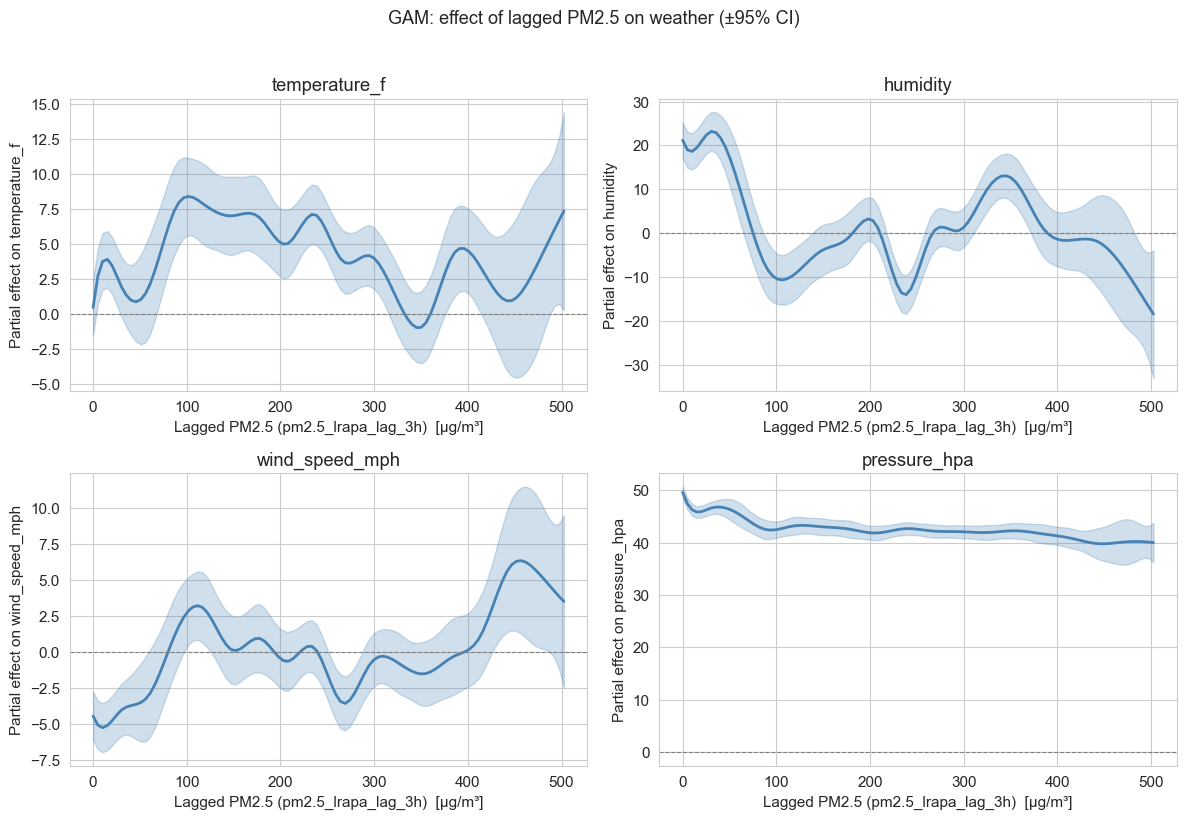

In [4]:
n_out = len(OUTCOMES)
n_cols = min(2, n_out)
n_rows = int(np.ceil(n_out / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, out in zip(axes, OUTCOMES):
    gam = fitted_gams[out]
    XX = gam.generate_X_grid(term=0)
    pdep, confi = gam.partial_dependence(term=0, X=XX, width=0.95)

    ax.fill_between(XX[:, 0], confi[:, 0], confi[:, 1], alpha=0.25, color='steelblue')
    ax.plot(XX[:, 0], pdep, color='steelblue', linewidth=2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f'Lagged PM2.5 ({PM_LAG_COL})  [µg/m³]')
    ax.set_ylabel(f'Partial effect on {out}')
    ax.set_title(out)

for ax in axes[n_out:]:
    ax.set_visible(False)

plt.suptitle('GAM: effect of lagged PM2.5 on weather (±95% CI)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/fig_gam_pm25_to_weather_partial.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Test-set diagnostics (predicted vs actual weather)

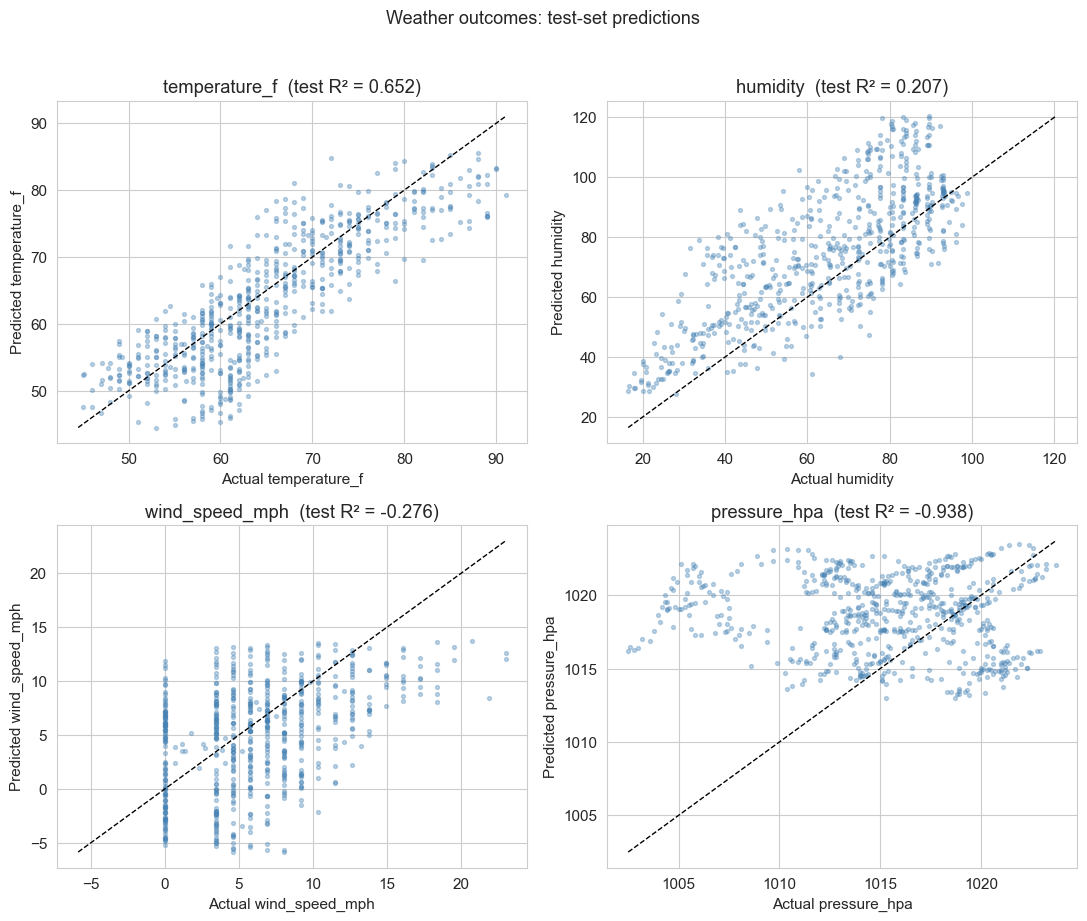

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()

for ax, out in zip(axes, OUTCOMES):
    gam = fitted_gams[out]
    y_te = test[out].values
    y_pr = gam.predict(X_test)
    te_r2 = metrics[out]['test_r2']

    ax.scatter(y_te, y_pr, s=8, alpha=0.35, color='steelblue')
    lo, hi = np.nanmin([y_te.min(), y_pr.min()]), np.nanmax([y_te.max(), y_pr.max()])
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
    ax.set_xlabel(f'Actual {out}')
    ax.set_ylabel(f'Predicted {out}')
    ax.set_title(f'{out}  (test R² = {te_r2:.3f})')

plt.suptitle('Weather outcomes: test-set predictions', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/fig_gam_pm25_to_weather_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Results summary

In [6]:
print('=' * 60)
print('GAM summary: lagged PM2.5 → weather (with hour + day-of-year controls)')
print('=' * 60)
print(f"Exposure column: {PM_LAG_COL}")
print(f"Control smooths: {CONTROL_COLS}")
print()

for out in OUTCOMES:
    m = metrics[out]
    print(f"{out:20s}  train R²={m['train_r2']:.3f}  test R²={m['test_r2']:.3f}  test RMSE={m['test_rmse']:.3f}")

print()
print('Smoothing λ for lagged-PM2.5 term (term 0) per outcome:')
for out in OUTCOMES:
    lam0 = fitted_gams[out].lam[0]
    lam_flat = np.asarray(lam0, dtype=float).ravel()
    lam_str = ', '.join(f'{v:.4f}' for v in lam_flat)
    print(f'  {out:20s}: {lam_str}')

GAM summary: lagged PM2.5 → weather (with hour + day-of-year controls)
Exposure column: pm2.5_lrapa_lag_3h
Control smooths: ['hour', 'dayofyear']

temperature_f         train R²=0.831  test R²=0.652  test RMSE=5.793
humidity              train R²=0.806  test R²=0.207  test RMSE=18.326
wind_speed_mph        train R²=0.371  test R²=-0.276  test RMSE=5.174
pressure_hpa          train R²=0.533  test R²=-0.938  test RMSE=6.435

Smoothing λ for lagged-PM2.5 term (term 0) per outcome:
  temperature_f       : 0.0631
  humidity            : 0.0631
  wind_speed_mph      : 0.0631
  pressure_hpa        : 0.0158


## 5. Per-event GAM: partial effects side by side

Fit the **same spec** separately on **Holiday Farm 2020** and **Cedar Creek 2022**.
If the partial effect of lagged PM2.5 on a weather outcome is **consistent across both events**
(same direction, similar magnitude) that is stronger evidence than a pooled result alone.
If it only appears in 2020 (the much larger smoke event) that indicates
the minimum exposure needed to detect a signal.



── Holiday Farm 2020  (train 1,435  test 359) ──
  temperature_f       train R²=+0.817  test R²=-8.024
  humidity            train R²=+0.831  test R²=-127.437
  wind_speed_mph      train R²=+0.453  test R²=-47.662
  pressure_hpa        train R²=+0.512  test R²=-14390.897

── Cedar Creek 2022  (train 1,151  test 288) ──
  temperature_f       train R²=+0.865  test R²=-559.802
  humidity            train R²=+0.850  test R²=-1311.098
  wind_speed_mph      train R²=+0.351  test R²=-6.500
  pressure_hpa        train R²=+0.482  test R²=-1551.999


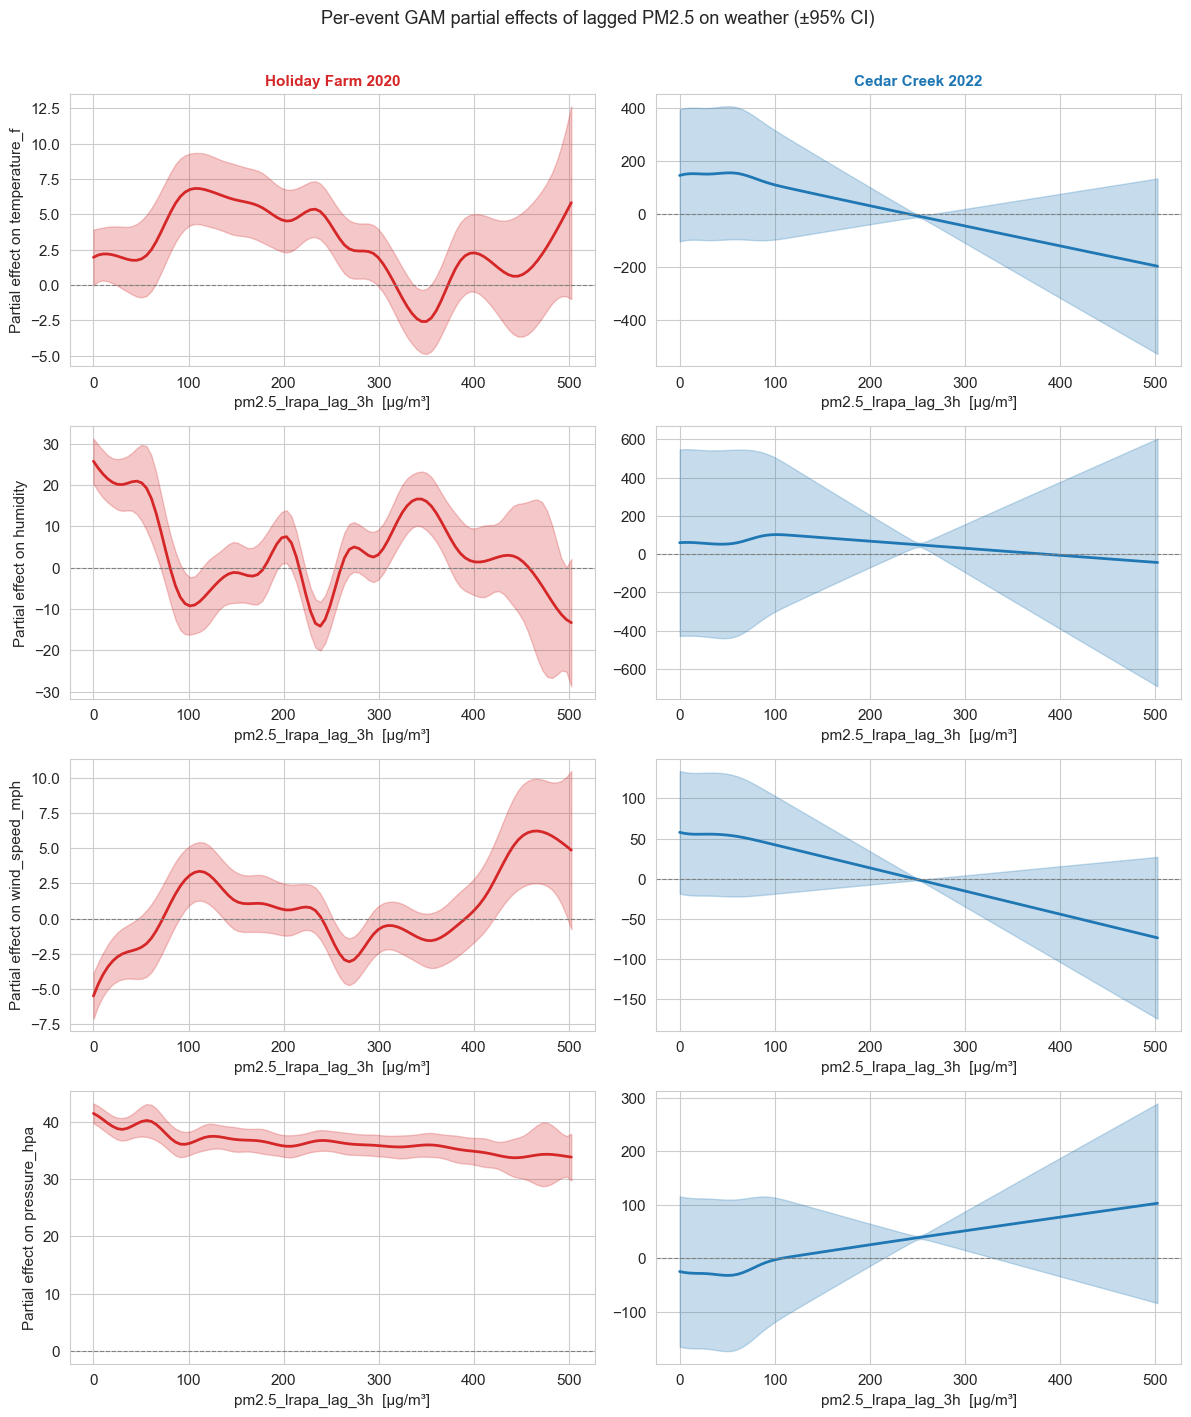

In [7]:
EVENTS = {
    'Holiday Farm 2020': df[df['event'] == 'Holiday Farm Fire 2020'],
    'Cedar Creek 2022':  df[df['event'] == 'Cedar Creek Fire 2022'],
}

event_colors = {'Holiday Farm 2020': '#d62728', 'Cedar Creek 2022': '#1f77b4'}
event_gams   = {}   # {event_name: {outcome: gam}}
event_metrics = {}  # {event_name: {outcome: {...}}}

for ev_name, ev_df in EVENTS.items():
    use = ev_df[['timestamp', PM_LAG_COL] + CONTROL_COLS + OUTCOMES].dropna()
    use = use.sort_values('timestamp').reset_index(drop=True).drop(columns=['timestamp'])
    si  = int(len(use) * 0.8)
    tr, te = use.iloc[:si], use.iloc[si:]
    Xtr = tr[FEATURE_COLS].values
    Xte = te[FEATURE_COLS].values
    event_gams[ev_name]    = {}
    event_metrics[ev_name] = {}
    print(f'\n── {ev_name}  (train {len(tr):,}  test {len(te):,}) ──')
    for out in OUTCOMES:
        gam_ev = LinearGAM(terms)
        gam_ev.gridsearch(Xtr, tr[out].values, progress=False)
        event_gams[ev_name][out] = gam_ev
        tr_r2 = r2_score(tr[out].values, gam_ev.predict(Xtr))
        te_r2 = r2_score(te[out].values, gam_ev.predict(Xte))
        event_metrics[ev_name][out] = {'train_r2': tr_r2, 'test_r2': te_r2}
        print(f'  {out:18s}  train R²={tr_r2:+.3f}  test R²={te_r2:+.3f}')

# ── Side-by-side partial effects ──
n_ev  = len(EVENTS)
n_out = len(OUTCOMES)
fig, axes = plt.subplots(n_out, n_ev,
                         figsize=(6 * n_ev, 3.5 * n_out),
                         squeeze=False)

for col_i, (ev_name, ev_gams) in enumerate(event_gams.items()):
    color = event_colors[ev_name]
    for row_i, out in enumerate(OUTCOMES):
        ax = axes[row_i, col_i]
        gam_ev = ev_gams[out]
        XX = gam_ev.generate_X_grid(term=0)
        pdep, confi = gam_ev.partial_dependence(term=0, X=XX, width=0.95)
        ax.fill_between(XX[:, 0], confi[:, 0], confi[:, 1], alpha=0.25, color=color)
        ax.plot(XX[:, 0], pdep, color=color, linewidth=2)
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        if row_i == 0:
            ax.set_title(ev_name, fontsize=11, color=color, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(f'Partial effect on {out}')
        ax.set_xlabel(f'{PM_LAG_COL}  [µg/m³]')

plt.suptitle('Per-event GAM partial effects of lagged PM2.5 on weather (±95% CI)',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/fig_gam_pm25_to_weather_partial.png',
            dpi=150, bbox_inches='tight')
plt.show()